# DS605: Fundamentals of Machine Learning
# Lab Assignment - 3
# Scikit-learn: Data Preprocessing and Model Performance Evaluation
# Dataset: Kaggle Hotel Booking Demand

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Part A - Data Loading and Preprocessing with Scikit-learn

# Task 1 - Load and Understand the Dataset

Dataset loaded successfully.
Shape: (119390, 32)
Number of rows: 119390
Number of columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64


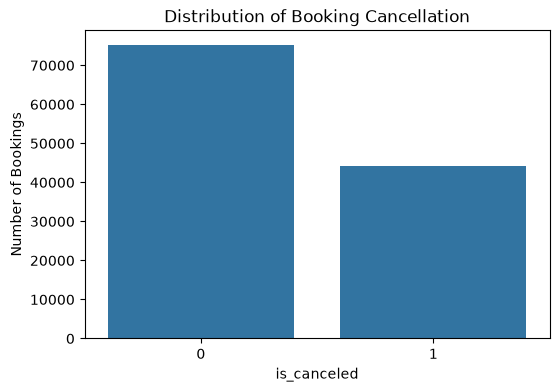

In [3]:
df = pd.read_csv("hotel_bookings.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.describe(include="all").T
df.dtypes
print("Class distribution of is_canceled:")
print(df["is_canceled"].value_counts())
class_percentage = df["is_canceled"].value_counts(normalize=True) * 100

print("Class distribution in percentage:")
print(class_percentage)
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_canceled")

plt.title("Distribution of Booking Cancellation")
plt.xlabel("is_canceled")
plt.ylabel("Number of Bookings")

plt.show()

# Task 2 - Missing Values, Leakage, and Outliers

Missing values in each column:
company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations    

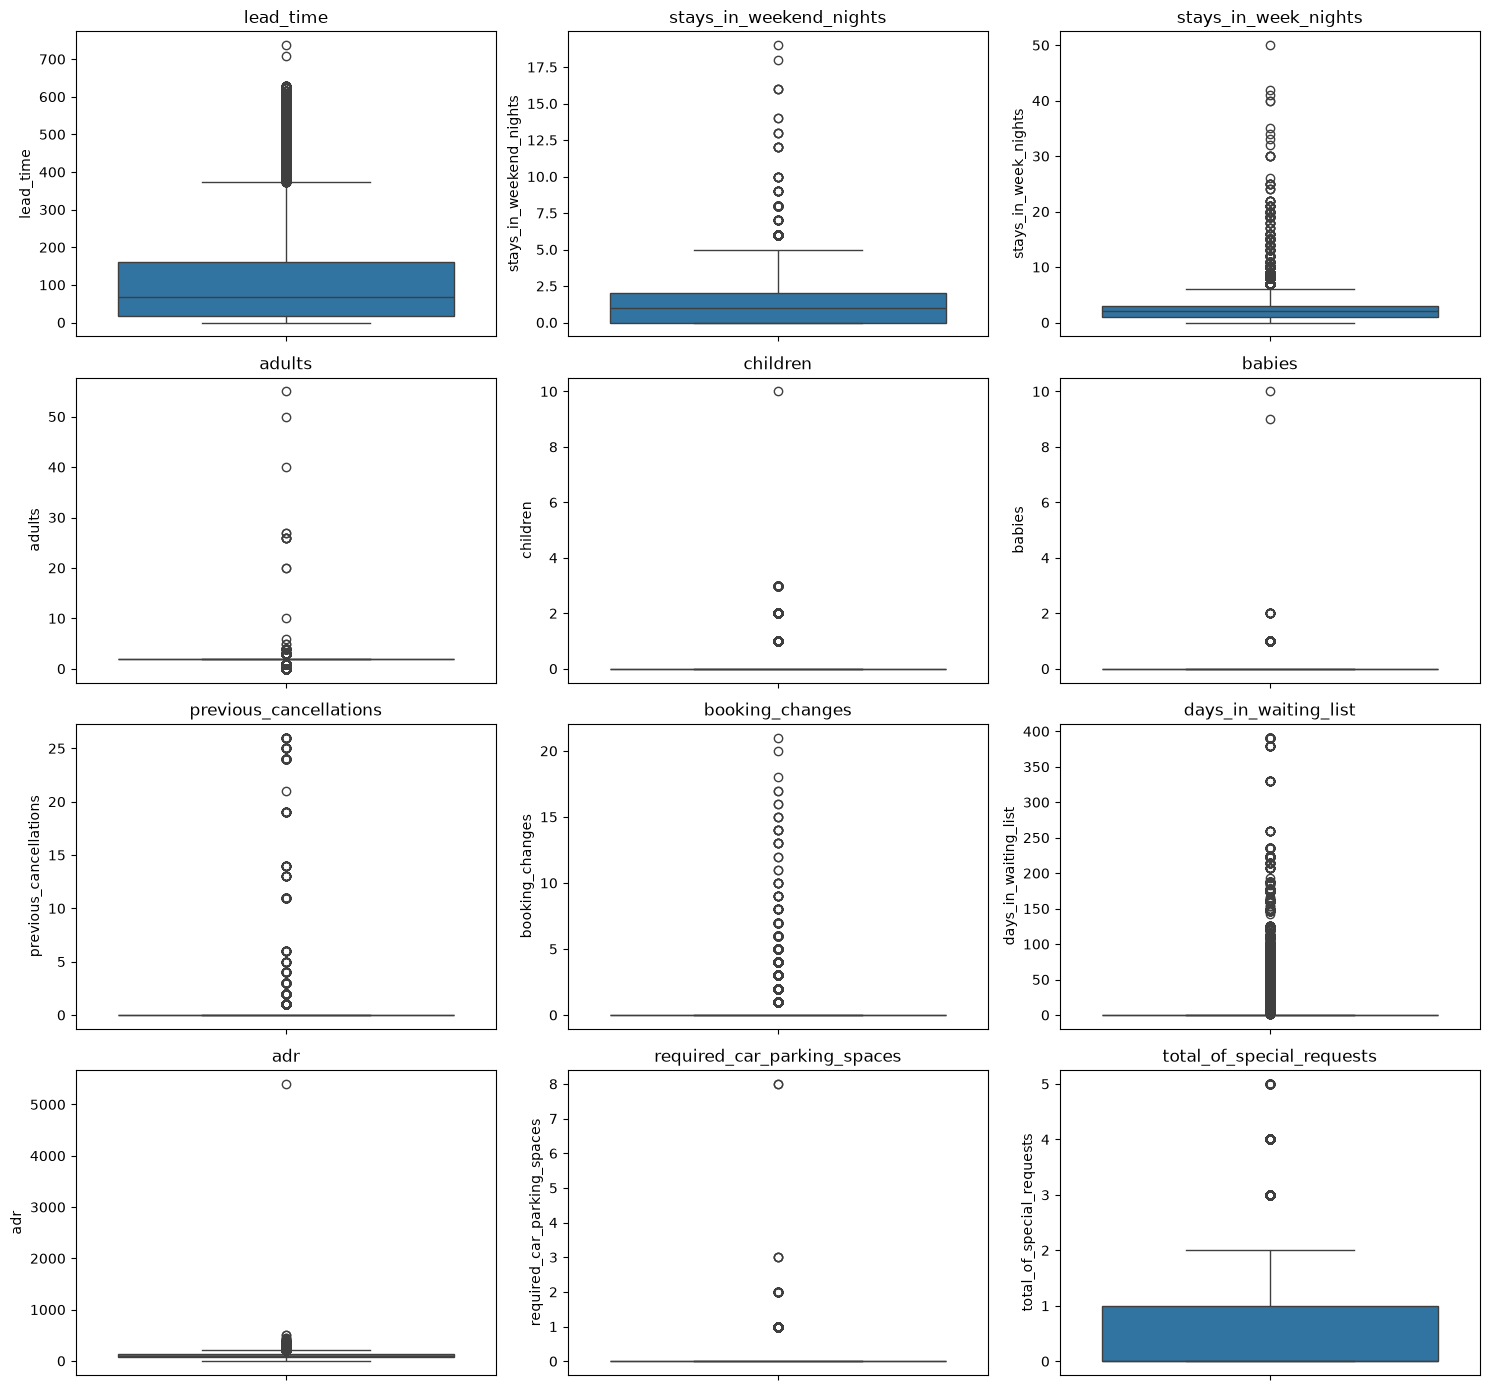

adr : 1
Rows before cleaning: 119390
Rows after cleaning: 119385
Rows removed: 5
Rows with zero adults, children and babies:
180
Rows before: 119385
Rows after: 119205
Rows removed: 180


In [4]:
missing_count = df.isnull().sum()

missing_count = missing_count.sort_values(ascending=False)

print("Missing values in each column:")
print(missing_count)
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table
missing_columns = missing_table[
    missing_table["Missing Count"] > 0
]

missing_columns
high_missing = missing_table[
    missing_table["Missing Percentage"] > 50
]

print("Columns with more than 50% missing values:")
print(high_missing)
# Columns that directly reveal the final booking outcome
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_columns)

print("Removed leakage columns:")
print(leakage_columns)

print("\nNew shape:", df.shape)
# company contains a very high percentage of missing values.
# It is therefore dropped rather than introducing unreliable information.

if "company" in df.columns:
    df = df.drop(columns=["company"])

print("Current dataset shape:", df.shape)
remaining_missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

remaining_missing = remaining_missing[
    remaining_missing["Missing Count"] > 0
].sort_values(by="Missing Percentage", ascending=False)

remaining_missing
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

#Outlier analysis
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)
#Boxplots
selected_outlier_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 14)
)

axes = axes.flatten()

for i, column in enumerate(selected_outlier_columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()
#IQR
def iqr_outlier_count(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return len(outliers), lower_bound, upper_bound


outlier_results = []

for column in selected_outlier_columns:
    count, lower, upper = iqr_outlier_count(df, column)
    
    outlier_results.append({
        "Column": column,
        "Outlier Count": count,
        "Lower Bound": lower,
        "Upper Bound": upper
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table

columns_that_cannot_be_negative = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

for column in columns_that_cannot_be_negative:
    negative_count = (df[column] < 0).sum()
    
    if negative_count > 0:
        print(column, ":", negative_count)
before_rows = len(df)

for column in columns_that_cannot_be_negative:
    df = df[df[column] >= 0]

after_rows = len(df)

removed_rows = before_rows - after_rows

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", removed_rows)
invalid_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print("Rows with zero adults, children and babies:")
print(len(invalid_guests))
before_rows = len(df)

df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
]

after_rows = len(df)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)


# Task 3 - Create Two Preprocessing Pipelines

In [5]:
y = df["is_canceled"]

X = df.drop(columns=["is_canceled"])

print("X shape:", X.shape)
print("y shape:", y.shape)
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nNumber of numerical features:", len(numeric_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))
numeric_preprocessor_standard = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]
)

numeric_preprocessor_minmax = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ]
)
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_preprocessor_standard,
            numeric_features
        ),
        (
            "cat",
            categorical_preprocessor,
            categorical_features
        )
    ]
)

print("Pipeline A created:")
print("KNNImputer + StandardScaler for numerical features")
print("Most Frequent Imputer + OneHotEncoder for categorical features")
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_preprocessor_minmax,
            numeric_features
        ),
        (
            "cat",
            categorical_preprocessor,
            categorical_features
        )
    ]
)

print("Pipeline B created:")
print("KNNImputer + MinMaxScaler for numerical features")
print("Most Frequent Imputer + OneHotEncoder for categorical features")


X shape: (119205, 28)
y shape: (119205,)
Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Number of numerical features: 18

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Number of categorical features: 10
Training data shape: (95364, 28)
Testing data shape: (23841, 28)

Training target distribution:
is_canceled
0    0.629252
1    0.370748
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629252
1    0.370748
Name: proportion, dtype: float64
Pipeline A created:
KNNImpute

# Part B - Model Training and Performance Evaluation
# Task 4 - Train Two Classification Models

In [8]:
logistic_standard = Pipeline(
    steps=[
        ("preprocessor", preprocessor_A),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_standard.fit(X_train, y_train)

print("Logistic Regression + StandardScaler trained successfully.")

Logistic Regression + StandardScaler trained successfully.


In [9]:
logistic_minmax = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_minmax.fit(X_train, y_train)

print("Logistic Regression + MinMaxScaler trained successfully.")

Logistic Regression + MinMaxScaler trained successfully.


In [12]:
tree_standard = Pipeline(
    steps=[
        ("preprocessor", preprocessor_A),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

tree_standard.fit(X_train, y_train)

print("Decision Tree + StandardScaler trained successfully.")

Decision Tree + StandardScaler trained successfully.


In [13]:
tree_minmax = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

tree_minmax.fit(X_train, y_train)

print("Decision Tree + MinMaxScaler trained successfully.")

Decision Tree + MinMaxScaler trained successfully.


# Task 5 - Evaluate and Compare the Four Results

Logistic Regression + StandardScaler: Train-Test Difference = -0.0004
  -> Small difference: relatively low indication of overfitting.

Logistic Regression + MinMaxScaler: Train-Test Difference = -0.0010
  -> Small difference: relatively low indication of overfitting.

Decision Tree + StandardScaler: Train-Test Difference = 0.1383
  -> Large difference: possible significant overfitting.

Decision Tree + MinMaxScaler: Train-Test Difference = 0.1385
  -> Large difference: possible significant overfitting.

Best Logistic Regression Result:
Model                    Logistic Regression
Preprocessing                 StandardScaler
Training Accuracy                   0.818139
Testing Accuracy                    0.818506
Precision                           0.811774
Recall                              0.664555
F1 Score                            0.730824
Train-Test Difference                -0.0004
Name: 0, dtype: object
Best Decision Tree Result:
Model                     Decision Tree
Preproc

<Figure size 600x500 with 0 Axes>

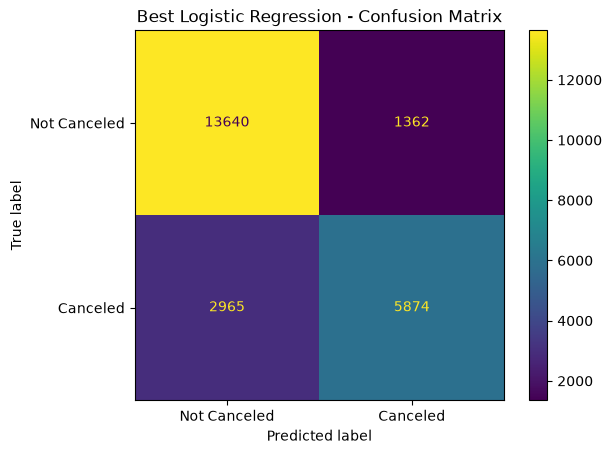

Confusion Matrix - Best Decision Tree
[[13250  1752]
 [ 1636  7203]]


<Figure size 600x500 with 0 Axes>

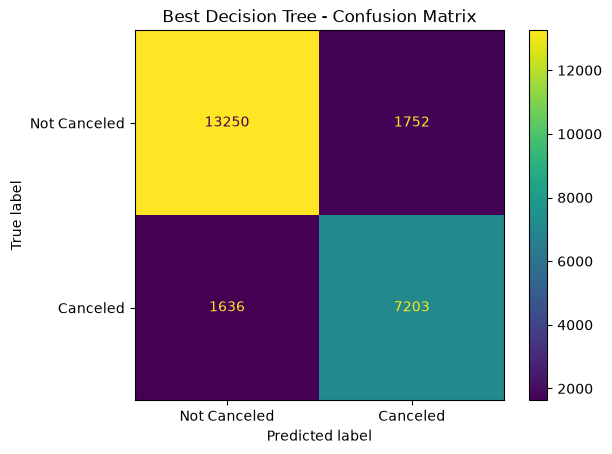

Classification Report - Best Logistic Regression
              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.86     15002
    Canceled       0.81      0.66      0.73      8839

    accuracy                           0.82     23841
   macro avg       0.82      0.79      0.80     23841
weighted avg       0.82      0.82      0.81     23841

Classification Report - Best Decision Tree
              precision    recall  f1-score   support

Not Canceled       0.89      0.88      0.89     15002
    Canceled       0.80      0.81      0.81      8839

    accuracy                           0.86     23841
   macro avg       0.85      0.85      0.85     23841
weighted avg       0.86      0.86      0.86     23841



In [14]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    results = {
        "Training Accuracy": accuracy_score(
            y_train,
            train_predictions
        ),
        
        "Testing Accuracy": accuracy_score(
            y_test,
            test_predictions
        ),
        
        "Precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        
        "Recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        
        "F1 Score": f1_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    }
    
    return results
results = []

models = {
    "Logistic Regression": {
        "StandardScaler": logistic_standard,
        "MinMaxScaler": logistic_minmax
    },
    
    "Decision Tree": {
        "StandardScaler": tree_standard,
        "MinMaxScaler": tree_minmax
    }
}

for model_name, preprocessing_models in models.items():
    
    for preprocessing_name, model in preprocessing_models.items():
        
        evaluation = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )
        
        results.append({
            "Model": model_name,
            "Preprocessing": preprocessing_name,
            **evaluation
        })

results_df = pd.DataFrame(results)

results_df
comparison_table = results_df.copy()

metric_columns = [
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

comparison_table[metric_columns] = comparison_table[
    metric_columns
].round(4)

comparison_table
comparison_sorted = comparison_table.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_sorted
results_df["Train-Test Difference"] = (
    results_df["Training Accuracy"] -
    results_df["Testing Accuracy"]
)

results_df["Train-Test Difference"] = results_df[
    "Train-Test Difference"
].round(4)

results_df
for _, row in results_df.iterrows():
    
    difference = row["Train-Test Difference"]
    
    print(
        f"{row['Model']} + {row['Preprocessing']}: "
        f"Train-Test Difference = {difference:.4f}"
    )
    
    if difference < 0.05:
        print("  -> Small difference: relatively low indication of overfitting.\n")
    elif difference < 0.10:
        print("  -> Moderate difference: some possible overfitting.\n")
    else:
        print("  -> Large difference: possible significant overfitting.\n")
logistic_results = results_df[
    results_df["Model"] == "Logistic Regression"
]

best_logistic_row = logistic_results.loc[
    logistic_results["F1 Score"].idxmax()
]

print("Best Logistic Regression Result:")
print(best_logistic_row)
tree_results = results_df[
    results_df["Model"] == "Decision Tree"
]

best_tree_row = tree_results.loc[
    tree_results["F1 Score"].idxmax()
]

print("Best Decision Tree Result:")
print(best_tree_row)
if best_logistic_row["Preprocessing"] == "StandardScaler":
    best_logistic_model = logistic_standard
else:
    best_logistic_model = logistic_minmax

logistic_predictions = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Confusion Matrix - Best Logistic Regression")
print(cm_logistic)
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()
if best_tree_row["Preprocessing"] == "StandardScaler":
    best_tree_model = tree_standard
else:
    best_tree_model = tree_minmax

tree_predictions = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    tree_predictions
)

print("Confusion Matrix - Best Decision Tree")
print(cm_tree)
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title("Best Decision Tree - Confusion Matrix")
plt.show()
print("Classification Report - Best Logistic Regression")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Not Canceled", "Canceled"],
        zero_division=0
    )
)
print("Classification Report - Best Decision Tree")
print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=["Not Canceled", "Canceled"],
        zero_division=0
    )
)

# Task 6 - Final Observations

BEST OVERALL MODEL
------------------
Model: Decision Tree
Preprocessing: StandardScaler
Testing Accuracy: 0.8579
Precision: 0.8044
Recall: 0.8149
F1 Score: 0.8096
Logistic Regression F1 Scores
StandardScaler: 0.7308
MinMaxScaler: 0.7255
Absolute difference: 0.0053
Decision Tree F1 Scores
StandardScaler: 0.8096
MinMaxScaler: 0.8094
Absolute difference: 0.0002
FINAL OBSERVATIONS
1. The best overall model based on F1-score is Decision Tree with StandardScaler.
2. Its testing accuracy is 0.8579 and its F1-score is 0.8096.
3. StandardScaler and MinMaxScaler produce very similar results for Logistic Regression.
4. Scaling has very little effect on Decision Tree performance, which is expected because decision trees are generally insensitive to feature scaling.
5. The train-test accuracy difference can be used to identify possible overfitting. A large difference indicates that the model performs substantially better on training data than unseen test data.
Cleaned dataset saved as: hotel_booki

<Figure size 600x500 with 0 Axes>

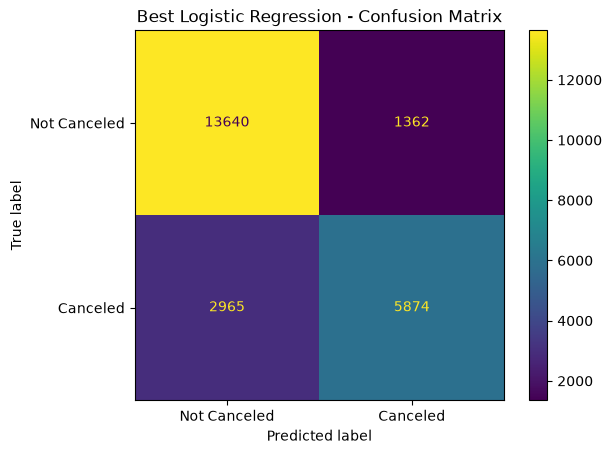

<Figure size 600x500 with 0 Axes>

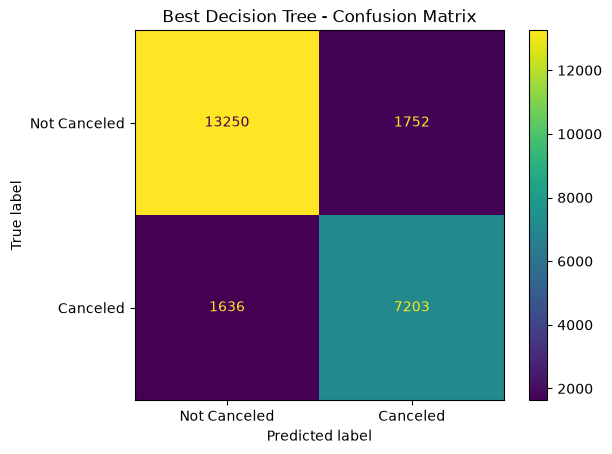

FINAL DATASET INFORMATION
Original/cleaned dataset shape: (119205, 29)

Target distribution:
is_canceled
0    75010
1    44195
Name: count, dtype: int64

Missing values remaining:
16756


MODEL COMPARISON


,Model,Preprocessing,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,StandardScaler,0.8181,0.8185,0.8118,0.6646,0.7308
1,Logistic Regression,MinMaxScaler,0.8148,0.8158,0.8104,0.6567,0.7255
2,Decision Tree,StandardScaler,0.9962,0.8579,0.8044,0.8149,0.8096
3,Decision Tree,MinMaxScaler,0.9962,0.8578,0.8042,0.8148,0.8094


In [15]:
best_overall = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("BEST OVERALL MODEL")
print("------------------")
print("Model:", best_overall["Model"])
print("Preprocessing:", best_overall["Preprocessing"])
print("Testing Accuracy:", round(best_overall["Testing Accuracy"], 4))
print("Precision:", round(best_overall["Precision"], 4))
print("Recall:", round(best_overall["Recall"], 4))
print("F1 Score:", round(best_overall["F1 Score"], 4))
lr_standard_f1 = results_df[
    (results_df["Model"] == "Logistic Regression") &
    (results_df["Preprocessing"] == "StandardScaler")
]["F1 Score"].iloc[0]

lr_minmax_f1 = results_df[
    (results_df["Model"] == "Logistic Regression") &
    (results_df["Preprocessing"] == "MinMaxScaler")
]["F1 Score"].iloc[0]

print("Logistic Regression F1 Scores")
print("StandardScaler:", round(lr_standard_f1, 4))
print("MinMaxScaler:", round(lr_minmax_f1, 4))

difference = abs(lr_standard_f1 - lr_minmax_f1)

print("Absolute difference:", round(difference, 4))
tree_standard_f1 = results_df[
    (results_df["Model"] == "Decision Tree") &
    (results_df["Preprocessing"] == "StandardScaler")
]["F1 Score"].iloc[0]

tree_minmax_f1 = results_df[
    (results_df["Model"] == "Decision Tree") &
    (results_df["Preprocessing"] == "MinMaxScaler")
]["F1 Score"].iloc[0]

print("Decision Tree F1 Scores")
print("StandardScaler:", round(tree_standard_f1, 4))
print("MinMaxScaler:", round(tree_minmax_f1, 4))

difference = abs(tree_standard_f1 - tree_minmax_f1)

print("Absolute difference:", round(difference, 4))
print("FINAL OBSERVATIONS")
print("==================")

print(
    f"1. The best overall model based on F1-score is "
    f"{best_overall['Model']} with {best_overall['Preprocessing']}."
)

print(
    f"2. Its testing accuracy is "
    f"{best_overall['Testing Accuracy']:.4f} and its F1-score is "
    f"{best_overall['F1 Score']:.4f}."
)

if abs(lr_standard_f1 - lr_minmax_f1) < 0.01:
    print(
        "3. StandardScaler and MinMaxScaler produce very similar "
        "results for Logistic Regression."
    )
else:
    print(
        "3. Scaling has a noticeable effect on Logistic Regression, "
        "as the two scaling methods produce different F1-scores."
    )

if abs(tree_standard_f1 - tree_minmax_f1) < 0.01:
    print(
        "4. Scaling has very little effect on Decision Tree performance, "
        "which is expected because decision trees are generally "
        "insensitive to feature scaling."
    )
else:
    print(
        "4. The Decision Tree results differ between the two scaling "
        "methods, although tree models are generally less sensitive "
        "to scaling."
    )

print(
    "5. The train-test accuracy difference can be used to identify "
    "possible overfitting. A large difference indicates that the model "
    "performs substantially better on training data than unseen test data."
)
cleaned_dataset_path = "hotel_bookings_cleaned.csv"

df.to_csv(
    cleaned_dataset_path,
    index=False
)

print("Cleaned dataset saved as:", cleaned_dataset_path)
print("Shape:", df.shape)
comparison_table.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison table saved as model_comparison.csv")
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title("Best Logistic Regression - Confusion Matrix")

plt.savefig(
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()

plt.title("Best Decision Tree - Confusion Matrix")

plt.savefig(
    "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("FINAL DATASET INFORMATION")
print("=========================")

print("Original/cleaned dataset shape:", df.shape)

print("\nTarget distribution:")
print(df["is_canceled"].value_counts())

print("\nMissing values remaining:")
print(df.isnull().sum().sum())

print("\n\nMODEL COMPARISON")
print("================")

display(comparison_table)
